<a href="https://www.kaggle.com/code/princelv84/airplanes-cars-ships?scriptVersionId=315650001" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 3-Class Image Classifier: Airplane / Automobile / Ship
### AIML with IIT Ropar  · MobileNetV2 Transfer Learning · TFLite Export

**Fixes applied in this version:**
1. `drop_remainder=True` on dataset loaders — safe MixUp / epoch-end batches  
2. Base model accessed by name (`get_layer(...)`) — not by fragile index  
3. Full `classification_report` + confusion matrix for per-class diagnostics  
4. INT8-aware TFLite export with `representative_dataset_gen`  
5. Horizontal-only `RandomFlip` (vertical is unrealistic for this domain)  
6. `CosineDecayRestarts` correctly passed to optimizer (not callbacks list)  
7. Grad-CAM fixed to use the functional API correctly  

**Dataset expected layout inside `dataset`:**
```
dataset/
  train/  airplane/  automobile/  ship/
  test/   airplane/  automobile/  ship/
```


## 0 · Install Dependencies

In [1]:
!pip install tensorflow scikit-learn opencv-python-headless pillow -q
print("Dependencies installed")

Dependencies installed


## 1 · Imports & GPU Check

In [2]:
import os, shutil, random, zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import matplotlib.pyplot as plt
import sklearn.metrics as skm

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU available: {len(gpus) > 0}  {gpus}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-04-30 19:34:16.396383: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777577656.774155      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777577656.886461      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777577657.858558      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777577657.858601      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777577657.858604      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU available: True  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2 · Load Dataset

Fetch  your `dataset` from kaggle.  
Expected structure inside the dataset directory:
```
dataset/
  train/  airplane/  automobile/  ship/
  test/   airplane/  automobile/  ship/
```


In [3]:
import os

source_dir = '/kaggle/input/datasets/princelv84/airplane-car-ship/dataset'

train_path = os.path.join(source_dir, 'train')
val_path   = os.path.join(source_dir, 'val')
test_path  = os.path.join(source_dir, 'test')

def safe_listdir(path):
    return sorted(os.listdir(path)) if os.path.exists(path) else f"[Missing] {path}"

print(f"\nDataset root   : {source_dir}")
print(f"Train folders  : {safe_listdir(train_path)}")
print(f"Val folders    : {safe_listdir(val_path)}")
print(f"Test folders   : {safe_listdir(test_path)}")


Dataset root   : /kaggle/input/datasets/princelv84/airplane-car-ship/dataset
Train folders  : ['airplane', 'automobile', 'ship']
Val folders    : ['airplane', 'automobile', 'ship']
Test folders   : ['airplane', 'automobile', 'ship']


## 3 · Train / Val / Test Split

Splits the **train/** folder 80 / 20 into `train/` and `val/`.  
The original **test/** folder is kept as a truly held-out test set — never seen during training or tuning.


In [4]:
FINAL_DIR = "data_split"
CLASSES   = ["airplane", "automobile", "ship"]
VAL_SPLIT = 0.2

# Auto-detect subfolder names (handles 'airplanes', 'cars', 'ships', etc.)
train_subfolders = sorted(os.listdir(os.path.join(source_dir, 'train')))
test_subfolders  = sorted(os.listdir(os.path.join(source_dir, 'test')))
assert len(train_subfolders) == 3 and len(test_subfolders) == 3, \
    f"Expected 3 class folders each, got {train_subfolders} / {test_subfolders}"

train_map = dict(zip(train_subfolders, CLASSES))
test_map  = dict(zip(test_subfolders,  CLASSES))
print("Folder → class mapping:", train_map)

# Rebuild split directory
if os.path.exists(FINAL_DIR):
    shutil.rmtree(FINAL_DIR)
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        os.makedirs(os.path.join(FINAL_DIR, split, cls), exist_ok=True)

IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

def split_and_copy(src, train_dst, val_dst, val_split=0.2, seed=42):
    files = [f for f in os.listdir(src) if f.lower().endswith(IMG_EXTS)]
    rng = random.Random(seed)
    rng.shuffle(files)
    n_val = int(len(files) * val_split)
    for i, f in enumerate(files[n_val:]):
        shutil.copy(os.path.join(src, f), os.path.join(train_dst, f"{i:05d}.jpg"))
    for i, f in enumerate(files[:n_val]):
        shutil.copy(os.path.join(src, f), os.path.join(val_dst, f"{i:05d}.jpg"))

def copy_all(src, dst):
    files = [f for f in os.listdir(src) if f.lower().endswith(IMG_EXTS)]
    for i, f in enumerate(files):
        shutil.copy(os.path.join(src, f), os.path.join(dst, f"{i:05d}.jpg"))

for folder, cls in train_map.items():
    split_and_copy(
        os.path.join(source_dir, 'train', folder),
        os.path.join(FINAL_DIR, 'train', cls),
        os.path.join(FINAL_DIR, 'val',   cls),
    )
for folder, cls in test_map.items():
    copy_all(os.path.join(source_dir, 'test', folder),
             os.path.join(FINAL_DIR, 'test', cls))

# Summary
print()
total = 0
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        n = len(os.listdir(os.path.join(FINAL_DIR, split, cls)))
        print(f"  {split:5s}/{cls:12s}: {n:4d} images")
        total += n
print(f"\nTotal images: {total}")

Folder → class mapping: {'airplane': 'airplane', 'automobile': 'automobile', 'ship': 'ship'}

  train/airplane    :  640 images
  train/automobile  :  640 images
  train/ship        :  640 images
  val  /airplane    :  160 images
  val  /automobile  :  160 images
  val  /ship        :  160 images
  test /airplane    :  189 images
  test /automobile  :  193 images
  test /ship        :  200 images

Total images: 2982


## 4 · tf.data Pipelines

**Fix:** `drop_remainder=True` prevents unequal-length batches at epoch end, which could cause silent shape mismatches when MixUp is used.


In [5]:
IMG_SIZE = 128
BATCH    = 32
AUTOTUNE = tf.data.AUTOTUNE

# Step 1: Load datasets (NO batching here)
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DIR, 'train'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=None,
    shuffle=True,
    seed=SEED,
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DIR, 'val'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=None,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(FINAL_DIR, 'test'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,   # keep test normal (do NOT drop samples)
    shuffle=False,
)

# Class info 
class_names = train_ds_raw.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

# Step 2: Apply batching manually (IMPORTANT)
train_ds_raw = train_ds_raw.batch(BATCH, drop_remainder=True)
val_ds = val_ds_raw.batch(BATCH, drop_remainder=True)

# Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
], name="augmentation")

# Step 3: Apply augmentation + prefetch
train_ds = (
    train_ds_raw
    .map(lambda x, y: (data_augmentation(x, training=True), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("\nPipelines ready")

Found 1920 files belonging to 3 classes.


I0000 00:00:1777577721.486880      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777577721.493029      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 480 files belonging to 3 classes.
Found 582 files belonging to 3 classes.
Classes: ['airplane', 'automobile', 'ship']

Pipelines ready


### 4a · Visualise Augmented Samples

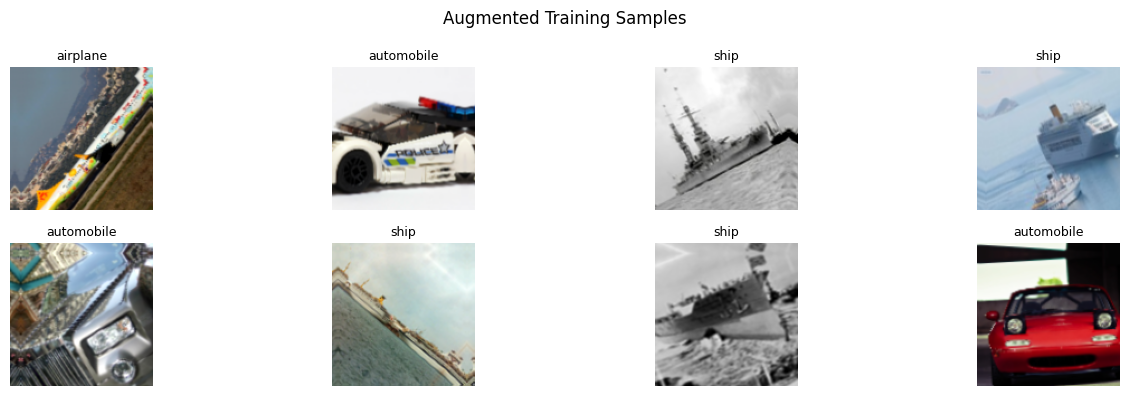

In [6]:
plt.figure(figsize=(14, 4))
for images, labels in train_ds.take(1):
    for i in range(min(8, len(images))):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]], fontsize=9)
        plt.axis("off")
plt.suptitle("Augmented Training Samples", fontsize=12)
plt.tight_layout()
plt.show()

### Concept Check: Why do we freeze the backbone?
When we add a new, randomly initialized dense layer (the "classification head") to our pre-trained MobileNetV2, it initially makes completely random predictions. 

If we were to train the entire network right away, the gradients calculated from these massive initial errors would be huge. These massive error signals would propagate backward through the network and **destroy** the carefully learned, delicate features already present in the MobileNetV2 backbone.

**The Strategy:**
1. **Phase 1 (Feature Extraction):** Freeze the backbone. Train *only* the new head so it learns to make basic sense of the features MobileNetV2 is already extracting.
2. **Phase 2 (Fine-Tuning):** Unfreeze the backbone (or just the top layers). Train the *entire* network with a very small learning rate to gently adapt the pre-trained features specifically to airplanes, cars, and ships without wrecking the foundational weights.

## 5 · Phase 1 — Feature Extraction (Frozen MobileNetV2)

Train only the new classification head with the backbone frozen.  
This warms up the head weights before fine-tuning.


In [7]:
BASE_NAME = f"mobilenetv2_1.00_{IMG_SIZE}"   # exact layer name used later

# Build model
base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False

inputs  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = layers.Rescaling(1.0 / 255)(inputs)
x       = base(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs, name="MobileNetV2_Classifier")
model.summary(expand_nested=False)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,227 (10.00 MB)

 Trainable params: 361,731 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [8]:
cb1 = [
    callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint("best_phase1.keras", monitor="val_accuracy",
                               save_best_only=True, verbose=1),
]

print("=" * 50)
print("PHASE 1 — Feature Extraction")
print("=" * 50)
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=cb1,
    verbose=1,
)

PHASE 1 — Feature Extraction
Epoch 1/15


I0000 00:00:1777577732.547410      82 service.cc:152] XLA service 0x7c7640011ad0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777577732.547452      82 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777577732.547457      82 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777577733.922565      82 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-30 19:35:43.547475: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:35:43.684201: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1777577746.679305      82 device_co

59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.7885 - loss: 0.5002
Epoch 1: val_accuracy improved from -inf to 0.99167, saving model to best_phase1.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 32s 202ms/step - accuracy: 0.7920 - loss: 0.4928 - val_accuracy: 0.9917 - val_loss: 0.0297 - learning_rate: 0.0010
Epoch 2/15
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9504 - loss: 0.1302
Epoch 2: val_accuracy improved from 0.99167 to 0.99375, saving model to best_phase1.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - accuracy: 0.9504 - loss: 0.1307 - val_accuracy: 0.9937 - val_loss: 0.0203 - learning_rate: 0.0010
Epoch 3/15
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9604 - loss: 0.1360
Epoch 3: val_accuracy improved from 0.99375 to 0.99583, saving model to best_phase1.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.9602 - loss: 0.1360 - val_accuracy: 0.9958 - val_loss: 0.0136 - learning_rate: 0.0010
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy:

## 6 · Phase 2 — Fine-Tuning (Unfreeze Top 30 Layers)

**Fix:** Base model accessed by name via `get_layer(BASE_NAME)` — not by fragile positional index.  
**Fix:** `CosineDecayRestarts` is a LR *schedule*, passed directly to the optimizer — not listed in callbacks.


In [9]:
# Load best phase-1 checkpoint
model = tf.keras.models.load_model("best_phase1.keras")

# access base by name, not by index 
base_layer = model.get_layer(BASE_NAME)
base_layer.trainable = True

UNFREEZE_FROM = len(base_layer.layers) - 30
for layer in base_layer.layers[:UNFREEZE_FROM]:
    layer.trainable = False

trainable_n = sum(1 for l in base_layer.layers if l.trainable)
print(f"Trainable base layers : {trainable_n} / {len(base_layer.layers)}")
total_params = model.count_params()
print(f"Total trainable params: {sum(p.numpy().size for p in model.trainable_variables):,}")

# CosineDecayRestarts goes INTO the optimizer, not callbacks
cosine_lr = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-5,
    first_decay_steps=5,
    t_mul=2.0,
    m_mul=0.8,
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=cosine_lr),   # ← FIX 4
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model recompiled")

Trainable base layers : 30 / 154
Total trainable params: 1,888,131
Model recompiled


In [10]:
cb2 = [
    callbacks.EarlyStopping(monitor="val_accuracy", patience=7,
                            restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint("best_finetuned.keras", monitor="val_accuracy",
                               save_best_only=True, verbose=1),
    # No ReduceLROnPlateau — cosine schedule is already in the optimizer
]

print("=" * 50)
print("PHASE 2 — Fine-Tuning")
print("=" * 50)
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=cb2,
    verbose=1,
)

PHASE 2 — Fine-Tuning
Epoch 1/30
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8734 - loss: 0.3514
Epoch 1: val_accuracy improved from -inf to 0.99583, saving model to best_finetuned.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 199ms/step - accuracy: 0.8740 - loss: 0.3495 - val_accuracy: 0.9958 - val_loss: 0.0086
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9014 - loss: 0.2905
Epoch 2: val_accuracy did not improve from 0.99583
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.9016 - loss: 0.2898 - val_accuracy: 0.9958 - val_loss: 0.0074
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9256 - loss: 0.2267
Epoch 3: val_accuracy did not improve from 0.99583
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.9253 - loss: 0.2272 - val_accuracy: 0.9958 - val_loss: 0.0076
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9259 - loss: 0.2098
Epoch 4: val_accuracy did not improve from 0.99583
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step

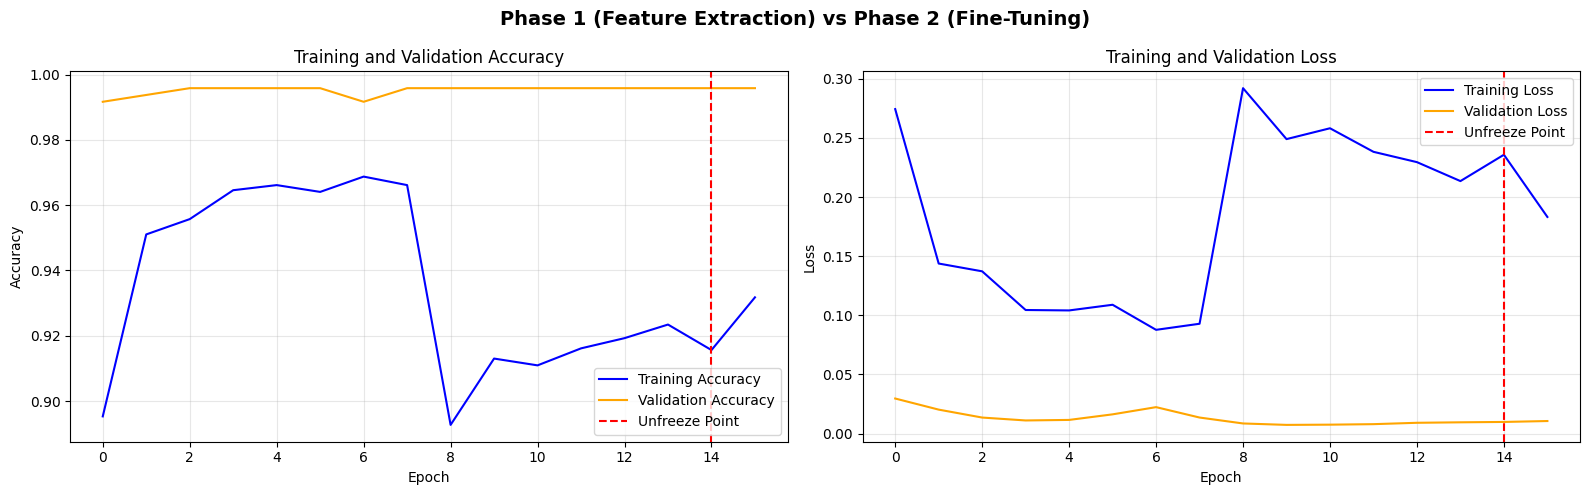

In [11]:
def plot_finetuning_history(history_phase1, history_phase2, initial_epochs):
    """Combines and plots the history of Phase 1 and Phase 2."""
    acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
    val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
    
    loss = history_phase1.history['loss'] + history_phase2.history['loss']
    val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

    plt.figure(figsize=(16, 5))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy', color='blue')
    plt.plot(val_acc, label='Validation Accuracy', color='orange')
    plt.axvline(x=initial_epochs-1, color='red', linestyle='--', label='Unfreeze Point')
    plt.title('Training and Validation Accuracy', fontsize=12)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss', color='blue')
    plt.plot(val_loss, label='Validation Loss', color='orange')
    plt.axvline(x=initial_epochs-1, color='red', linestyle='--', label='Unfreeze Point')
    plt.title('Training and Validation Loss', fontsize=12)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.suptitle("Phase 1 (Feature Extraction) vs Phase 2 (Fine-Tuning)", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

plot_finetuning_history(history1, history2, initial_epochs=15)

## 7 · Training Curves

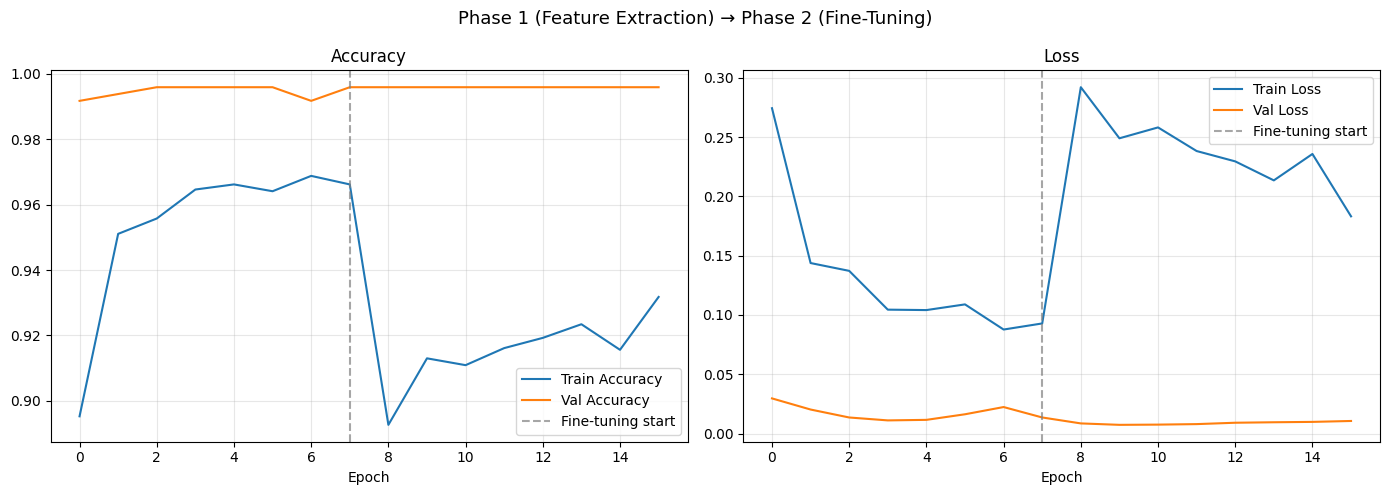

Saved training_curves.png


In [12]:
def plot_history(h1, h2):
    acc   = h1.history["accuracy"]     + h2.history["accuracy"]
    vacc  = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss  = h1.history["loss"]         + h2.history["loss"]
    vloss = h1.history["val_loss"]     + h2.history["val_loss"]
    ph1   = len(h1.history["accuracy"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, tr, val, title in zip(axes,
                                   [acc, loss], [vacc, vloss],
                                   ["Accuracy", "Loss"]):
        ax.plot(tr,  label=f"Train {title}")
        ax.plot(val, label=f"Val {title}")
        ax.axvline(ph1 - 1, color="gray", linestyle="--",
                   label="Fine-tuning start", alpha=0.7)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)
    plt.suptitle("Phase 1 (Feature Extraction) → Phase 2 (Fine-Tuning)", fontsize=13)
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("Saved training_curves.png")

plot_history(history1, history2)

## 8 · Full Evaluation

**Fix:** Added `classification_report` and confusion matrix for per-class precision / recall.  
Evaluates on both **val** (to match training monitoring) and the truly held-out **test** set.


In [13]:
best_model = tf.keras.models.load_model("best_finetuned.keras")

# Aggregate metrics
val_loss,  val_acc  = best_model.evaluate(val_ds,  verbose=0)
test_loss, test_acc = best_model.evaluate(test_ds, verbose=0)

print(f"{'─'*45}")
print(f"  Val  Accuracy : {val_acc*100:6.2f}%   Loss: {val_loss:.4f}")
print(f"  Test Accuracy : {test_acc*100:6.2f}%   Loss: {test_loss:.4f}  ← unbiased")
print(f"{'─'*45}")

2026-04-30 19:38:36.371359: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:38:36.510524: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:38:36.645674: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


─────────────────────────────────────────────
  Val  Accuracy :  99.58%   Loss: 0.0086
  Test Accuracy :  99.66%   Loss: 0.0094  ← unbiased
─────────────────────────────────────────────


In [14]:
# Per-class classification report
def evaluate_detailed(ds, split_name):
    y_true, y_pred = [], []
    for images, labels in ds:
        preds = best_model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    print(f"\n{'='*50}")
    print(f"  Classification Report — {split_name}")
    print(f"{'='*50}")
    print(skm.classification_report(y_true, y_pred, target_names=class_names, digits=3))
    return y_true, y_pred

# Validate on both splits
y_true_val, y_pred_val   = evaluate_detailed(val_ds,  "Validation Set")
y_true_test, y_pred_test = evaluate_detailed(test_ds, "Test Set (held-out)")


  Classification Report — Validation Set
              precision    recall  f1-score   support

    airplane      1.000     0.988     0.994       160
  automobile      0.988     1.000     0.994       160
        ship      1.000     1.000     1.000       160

    accuracy                          0.996       480
   macro avg      0.996     0.996     0.996       480
weighted avg      0.996     0.996     0.996       480


  Classification Report — Test Set (held-out)
              precision    recall  f1-score   support

    airplane      0.995     0.995     0.995       189
  automobile      1.000     1.000     1.000       193
        ship      0.995     0.995     0.995       200

    accuracy                          0.997       582
   macro avg      0.997     0.997     0.997       582
weighted avg      0.997     0.997     0.997       582



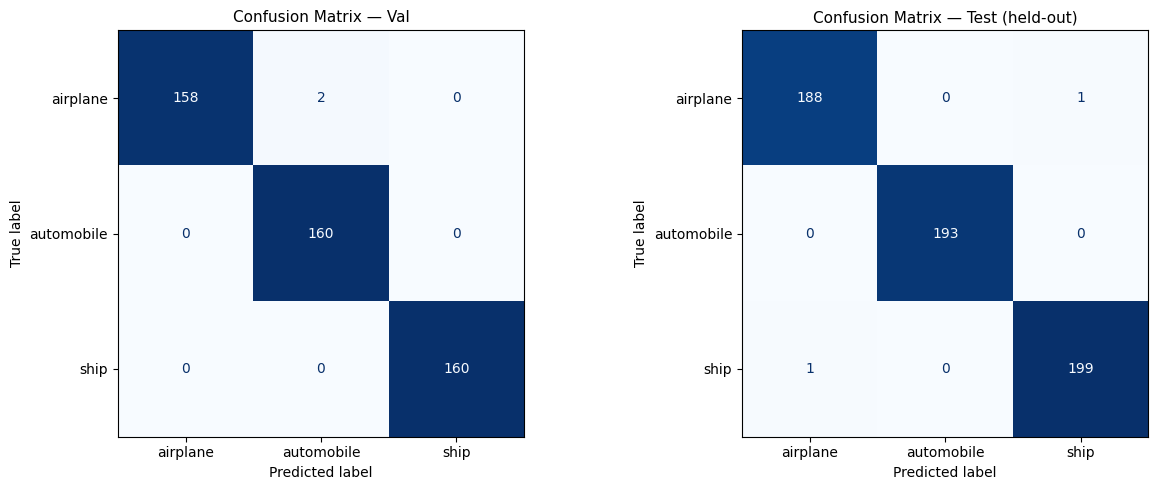

Saved confusion_matrices.png


In [15]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_true_val, y_true_test],
    [y_pred_val, y_pred_test],
    ["Confusion Matrix — Val", "Confusion Matrix — Test (held-out)"]
):
    cm   = skm.confusion_matrix(y_true, y_pred)
    disp = skm.ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()
print("Saved confusion_matrices.png")

## 9 · Visualise Misclassified Samples

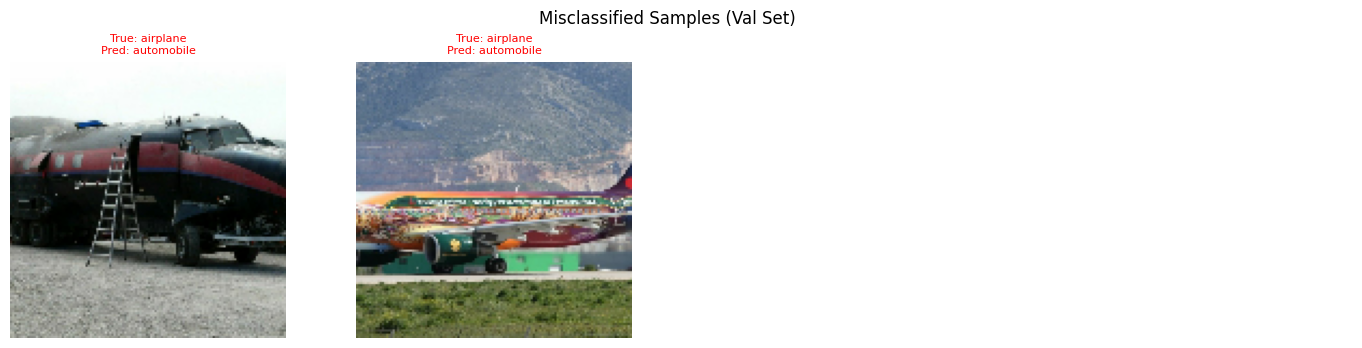

In [16]:
MAX_SHOW = 12
wrong_imgs, wrong_true, wrong_pred = [], [], []

for images, labels in val_ds:
    preds = best_model.predict(images, verbose=0)
    for img, true, prob in zip(images.numpy(), labels.numpy(), preds):
        p = np.argmax(prob)
        if p != true:
            wrong_imgs.append(img.astype("uint8"))
            wrong_true.append(true)
            wrong_pred.append(p)
        if len(wrong_imgs) >= MAX_SHOW:
            break
    if len(wrong_imgs) >= MAX_SHOW:
        break

if wrong_imgs:
    cols = 4
    rows = (len(wrong_imgs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    axes = axes.flatten()
    for ax, img, t, p in zip(axes, wrong_imgs, wrong_true, wrong_pred):
        ax.imshow(img)
        ax.set_title(f"True: {class_names[t]}\nPred: {class_names[p]}", fontsize=8,
                     color="red")
        ax.axis("off")
    for ax in axes[len(wrong_imgs):]:
        ax.axis("off")
    plt.suptitle("Misclassified Samples (Val Set)", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified images found in the validation set!")

## 10 · Grad-CAM Visualisation

Shows which image regions drove the model's prediction.  
**Fix:** Uses the functional API correctly — gradients taken w.r.t. the last conv feature map.


### Model Interpretability: Grad-CAM
Deep learning models are often treated as "black boxes." Gradient-weighted Class Activation Mapping (Grad-CAM) helps us peer inside by using the gradients of the target concept to produce a coarse localization map. This heatmap highlights the regions in the image that were most important for predicting the concept.

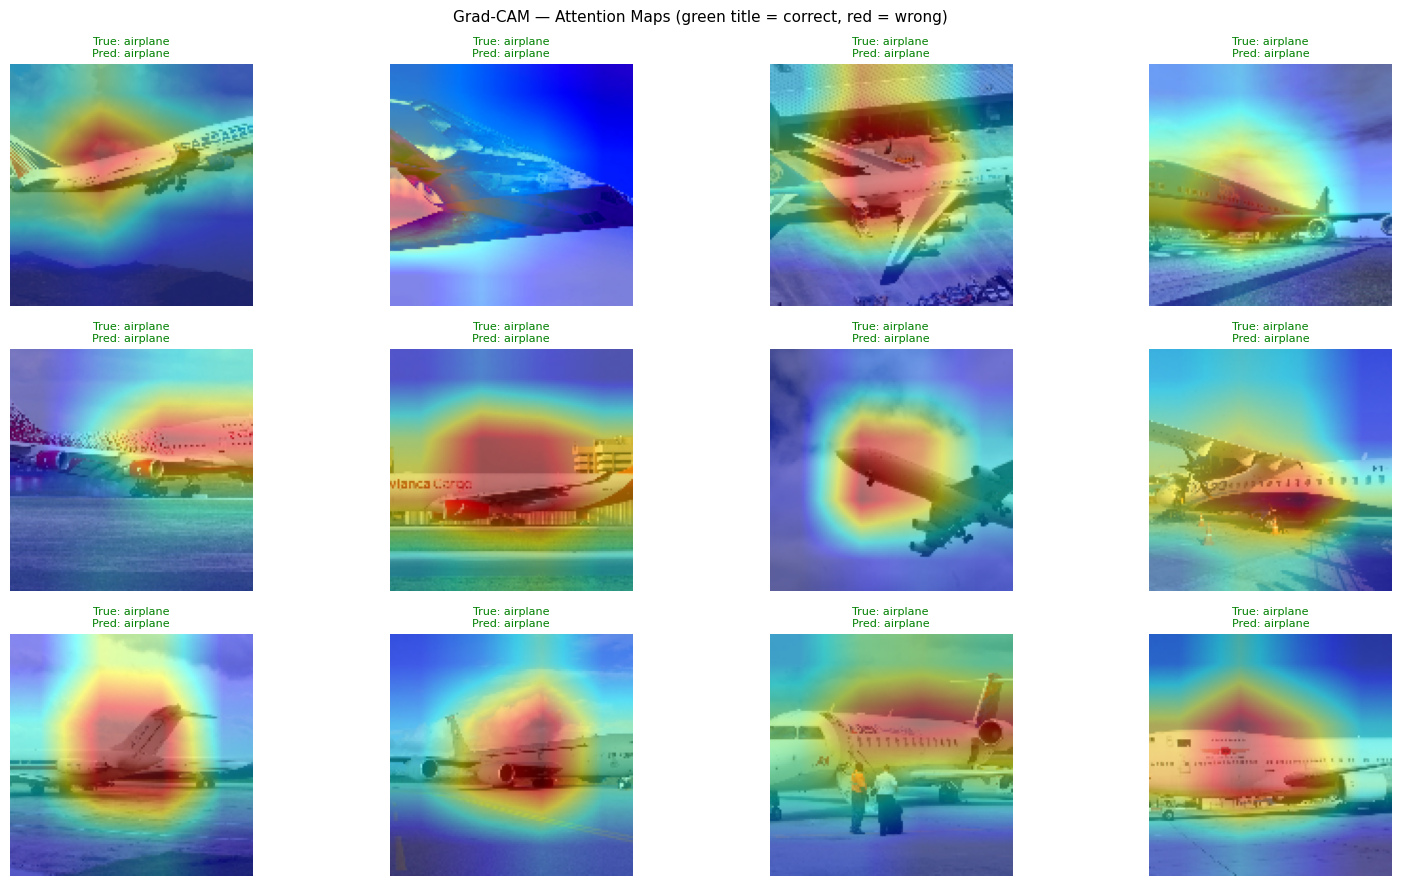

In [17]:
# 1. GRAD-CAM FUNCTION
def make_gradcam_heatmap(img_array, model, base_model_name, last_conv_layer_name): 
    # Extract the nested base model
    base_model = model.get_layer(base_model_name)

    # Create a sub-model strictly for the inner base_model.
    # EXPLICITLY using `inputs=` and `outputs=` fixes the "too many positional arguments" error!
    grad_model = tf.keras.models.Model(
        inputs=base_model.inputs,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    # Identify layers before and after the base_model (Augmentations, Dense heads, etc.)
    layers_before = []
    layers_after = []
    passed_base = False
    
    for layer in model.layers:
        if layer.name == base_model_name:
            passed_base = True
            continue
            
        # Skip InputLayers to avoid invocation errors
        if isinstance(layer, tf.keras.layers.InputLayer):
            continue
            
        if not passed_base:
            layers_before.append(layer)
        else:
            layers_after.append(layer)

    with tf.GradientTape() as tape:
        # Forward pass: Layers BEFORE base model (e.g., Augmentation)
        x = img_array
        for layer in layers_before:
            x = layer(x)

        # Forward pass: Base model
        conv_out, base_out = grad_model(x)

        # Explicitly tell the tape to track the inner convolutional output
        tape.watch(conv_out)

        # Forward pass: Layers AFTER base model (e.g., GAP, Dropout, Dense)
        preds = base_out
        for layer in layers_after:
            preds = layer(preds)

        # Get highest predicted class
        pred_idx = tf.argmax(preds[0])
        class_channel = preds[:, pred_idx]

    # Calculate gradients
    grads = tape.gradient(class_channel, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Generate heatmap
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()
    heatmap = np.maximum(heatmap, 0)
    
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
        
    return heatmap, class_names[pred_idx.numpy()]


# 2. OVERLAY FUNCTION
def overlay_gradcam(orig_img, heatmap, alpha=0.45):
    import cv2
    h, w = orig_img.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = (heatmap_colored * alpha + orig_img * (1 - alpha)).astype(np.uint8)
    return overlay


# 3. PLOTTING LOOP
BASE_NAME = "mobilenetv2_1.00_128" # Check model.summary() to ensure this matches exactly!
LAST_CONV = "out_relu"             # last activation in MobileNetV2

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
sample_idx = 0

for images, labels in val_ds.take(3):
    for i in range(min(4, len(images))):
        img_np = images[i].numpy().astype("uint8")
        inp    = np.expand_dims(images[i].numpy().astype(np.float32), 0)

        try:
            # Calling the 4-argument function properly
            heatmap, pred_cls = make_gradcam_heatmap(inp, best_model, BASE_NAME, LAST_CONV)
            overlay = overlay_gradcam(img_np, heatmap)
            axes[sample_idx // 4, sample_idx % 4].imshow(overlay)
        except Exception as e:
            # Print the error so you can see exactly why it failed if it happens again
            print(f"Error processing image {sample_idx}: {e}")
            axes[sample_idx // 4, sample_idx % 4].imshow(img_np)
            pred_cls = "err"

        true_cls = class_names[labels[i].numpy()]
        axes[sample_idx // 4, sample_idx % 4].set_title(
            f"True: {true_cls}\nPred: {pred_cls}",
            fontsize=8,
            color="green" if pred_cls == true_cls else "red"
        )
        axes[sample_idx // 4, sample_idx % 4].axis("off")
        
        sample_idx += 1
        if sample_idx >= 12:
            break
            
    if sample_idx >= 12:
        break

plt.suptitle("Grad-CAM — Attention Maps (green title = correct, red = wrong)", fontsize=11)
plt.tight_layout()
plt.savefig("gradcam.png", dpi=150)
plt.show()

## 11 · TFLite Export — Full INT8 Quantization

**Fix:** Provides a `representative_dataset_gen` for proper INT8 quantization (better accuracy-size tradeoff than dynamic-range-only).  
Input/output kept as `float32` for easy deployment flexibility.


In [18]:
# representative dataset for INT8 calibration
def representative_data_gen():
    """Yields 50 calibration batches — used only for INT8 scale/zero-point estimation."""
    for images, _ in val_ds.take(50):
        yield [tf.cast(images, tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations               = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset      = representative_data_gen
converter.target_spec.supported_ops   = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.TFLITE_BUILTINS,    # fallback for unsupported ops
]
converter.inference_input_type  = tf.float32   # keep float I/O for flexibility
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

tflite_path = "model_int8.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

size_mb = len(tflite_model) / 1e6
print(f"TFLite model saved  →  {tflite_path}  ({size_mb:.2f} MB)")

INFO:tensorflow:Assets written to: /tmp/tmpvk802_c4/assets


INFO:tensorflow:Assets written to: /tmp/tmpvk802_c4/assets


Saved artifact at '/tmp/tmpvk802_c4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136847118375760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136847118377872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136847118377680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136847118376720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136847118378448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136847118377104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136847118379024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136847118377296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136847118378256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136847118379600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1368471183755

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1777577949.875468      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777577949.875497      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777577950.026984      23 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


TFLite model saved  →  model_int8.tflite  (3.08 MB)


fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32


In [19]:
# Sanity-check TFLite inference
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
inp_idx = interpreter.get_input_details()[0]["index"]
out_idx = interpreter.get_output_details()[0]["index"]

correct, total = 0, 0
for images, labels in val_ds.take(10):
    for img, label in zip(images.numpy(), labels.numpy()):
        inp = np.expand_dims(img.astype(np.float32), 0)
        interpreter.set_tensor(inp_idx, inp)
        interpreter.invoke()
        pred = np.argmax(interpreter.get_tensor(out_idx))
        correct += int(pred == label)
        total   += 1

print(f"TFLite sanity-check accuracy: {correct/total*100:.1f}%  on {total} samples")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


TFLite sanity-check accuracy: 99.4%  on 320 samples


## 12 · Single-Image Inference

Upload any image and get the model's prediction with confidence scores.


2026-04-30 19:39:37.434706: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:39:37.584471: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 19:39:37.718066: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


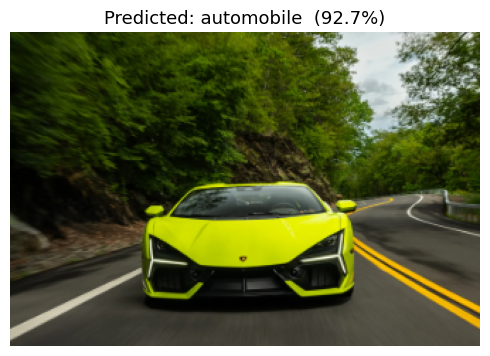


All class probabilities:
automobile  :  92.69%  █████████████████████████████████████
airplane    :   5.74%  ██
ship        :   1.57%  


In [20]:
import numpy as np
import cv2
import requests
import matplotlib.pyplot as plt

IMG_SIZE = 224  # ensure this matches your training config

url = "https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/test1.png"

# --- Fetch image ---
resp = requests.get(url, timeout=10)
resp.raise_for_status()

img_array = np.frombuffer(resp.content, np.uint8)
img_bgr = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

if img_bgr is None:
    raise ValueError("Failed to decode image from URL")

# Preprocess
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

inp = np.expand_dims(img_resized.astype(np.float32), 0)  # (1, H, W, 3)

# IMPORTANT: match training preprocessing
# If you used normalization like /255 during training, add:
# inp = inp / 255.0

# --- Inference ---
probs = best_model.predict(inp, verbose=0)[0]
pred_idx  = np.argmax(probs)
pred_name = class_names[pred_idx]

# --- Visualization ---
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title(f"Predicted: {pred_name}  ({probs[pred_idx]*100:.1f}%)", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()

# --- Probabilities ---
print("\nAll class probabilities:")
for name, p in sorted(zip(class_names, probs), key=lambda x: -x[1]):
    bar = "█" * int(p * 40)
    print(f"{name:12s}: {p*100:6.2f}%  {bar}")

## 13 · Save & Download All Outputs

In [21]:
import os
import shutil

OUTPUT_DIR = "/kaggle/working/exports"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save TFLite model
if os.path.exists("model_int8.tflite"):
    shutil.copy("model_int8.tflite", f"{OUTPUT_DIR}/model_int8.tflite")
    print("model_int8.tflite saved")

# Save training artifacts
artifact_files = [
    "training_curves.png",
    "confusion_matrices.png",
    "gradcam.png"
]

for fname in artifact_files:
    if os.path.exists(fname):
        shutil.copy(fname, f"{OUTPUT_DIR}/{fname}")
        print(f" {fname} saved")

# Save Keras model
best_model.save(f"{OUTPUT_DIR}/best_model_final.keras")
print("best_model_final.keras saved")

# Optional: Zip everything for easy download 
zip_path = "/kaggle/working/model_artifacts.zip"
shutil.make_archive(zip_path.replace(".zip", ""), 'zip', OUTPUT_DIR)

print(f"\n All files packaged at: {zip_path}")

model_int8.tflite saved
 training_curves.png saved
 confusion_matrices.png saved
 gradcam.png saved
best_model_final.keras saved

 All files packaged at: /kaggle/working/model_artifacts.zip


# **Live Demo:**

# [https://lovnishverma-airplane-car-ship-classifier.hf.space](http://)
